<a href="https://colab.research.google.com/github/Sachith308/Statistical-Learning-e23308/blob/main/gpr_lr_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [1]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [4]:
import os
import pandas as pd
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(path + "/ENB2012_data.csv")

print(df.head())
print(df.info())
print(df.describe())

     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB
None
               X1      

          Y1        Y2
Y1  1.000000  0.975862
Y2  0.975862  1.000000


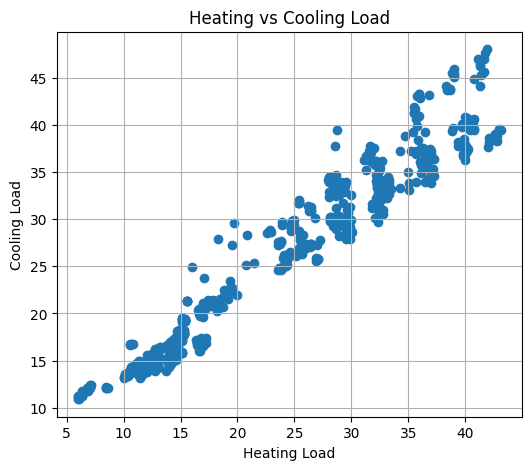

In [6]:
corr = df[['Y1','Y2']].corr()
print(corr)

plt.figure(figsize=(6,5))
plt.scatter(df['Y1'], df['Y2'])
plt.xlabel('Heating Load')
plt.ylabel('Cooling Load')
plt.title('Heating vs Cooling Load')
plt.grid(True)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.iloc[:,0:8].values

y_heat = df['Y1'].values
y_cool = df['Y2'].values

X_train, X_test, y_heat_train, y_heat_test = train_test_split(
    X, y_heat, test_size=0.2, random_state=42
)

_, _, y_cool_train, y_cool_test = train_test_split(
    X, y_cool, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel()

gpr_heat = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_heat.fit(X_train_scaled, y_heat_train)

heat_pred, heat_std = gpr_heat.predict(
    X_test_scaled,
    return_std=True
)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [9]:
gpr_heat = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

In [10]:
gpr_heat = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

In [11]:
gpr_heat.fit(X_train_scaled, y_heat_train)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1),
                         n_restarts_optimizer=10, normalize_y=True,
                         random_state=42)

In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

heat_pred, heat_std = gpr_heat.predict(
    X_test_scaled,
    return_std=True
)

r2_heat = r2_score(y_heat_test, heat_pred)
rmse_heat = np.sqrt(mean_squared_error(y_heat_test, heat_pred))

In [15]:
print(gpr_heat.kernel_)
print("R² =", r2_heat)
print("RMSE =", rmse_heat)

316**2 * RBF(length_scale=11.9) + WhiteKernel(noise_level=0.00144)
R² = 0.997723015453579
RMSE = 0.48716899330996344


In [16]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_heat = r2_score(y_heat_test, heat_pred)
rmse_heat = np.sqrt(mean_squared_error(y_heat_test, heat_pred))

print(gpr_heat.kernel_)
print("R² =", r2_heat)
print("RMSE =", rmse_heat)

316**2 * RBF(length_scale=11.9) + WhiteKernel(noise_level=0.00144)
R² = 0.997723015453579
RMSE = 0.48716899330996344


In [18]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel()

gpr_cool = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

In [19]:
gpr_cool.fit(X_train_scaled, y_cool_train)

cool_pred, cool_std = gpr_cool.predict(
    X_test_scaled,
    return_std=True
)

r2_cool = r2_score(y_cool_test, cool_pred)
rmse_cool = np.sqrt(mean_squared_error(y_cool_test, cool_pred))

print(gpr_cool.kernel_)
print("R² =", r2_cool)
print("RMSE =", rmse_cool)

20.2**2 * RBF(length_scale=1.87) + WhiteKernel(noise_level=0.995)
R² = 0.9804960828501308
RMSE = 1.3443136058949312


###1. Model performance<br>
- Both models perform very well, especially Heating Load.<br>
- Heating Load prediction is almost perfect (≈99.8% variance explained).<br>
- Cooling Load is slightly harder but still excellent (~98% accuracy).<br>

This difference is normal because:

- Cooling load depends more on external environmental variability.<br>
- Heating load in this dataset is more directly controlled by building geometry features.

###2. Error analysis<br>
- Heating RMSE ≈ 0.49 → very small error<br>
- Cooling RMSE ≈ 1.34 → slightly higher but still low relative to dataset scale


# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [20]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [23]:
import os
import pandas as pd

print(f"Listing contents of: {path}")
!ls {path}

df2 = pd.read_csv(path + "/green_building_dataset.csv")
df2.head()

Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


In [28]:
import pandas as pd

df = pd.read_csv(path + "/green_building_dataset.csv")

print(df.head())
print(df.info())

   indoor_temperature  indoor_humidity  co2_concentration  indoor_lighting  \
0           22.494481        43.624167         554.345944       432.115959   
1           29.408572        32.868476         466.383802       221.965186   
2           26.783927        46.385156        1850.558681       566.559664   
3           25.183902        42.448700         663.712464       201.348306   
4           19.872224        57.084826        1705.062755       940.588677   

   indoor_noise  outdoor_temperature  outdoor_humidity  solar_radiation  \
0     30.958646            24.443784         22.670752       540.768233   
1     68.624892            -1.398534         50.087239       699.959413   
2     38.547245             5.904842         24.415262       828.108509   
3     32.195231            29.815571         75.240077       791.541006   
4     62.684935            18.790863         57.069417       882.605624   

   wind_speed   rainfall  electricity_consumption  heating_energy  \
0    0.3333

In [29]:
y = df["predicted_energy_demand"]
X = df.drop(columns=["predicted_energy_demand"])

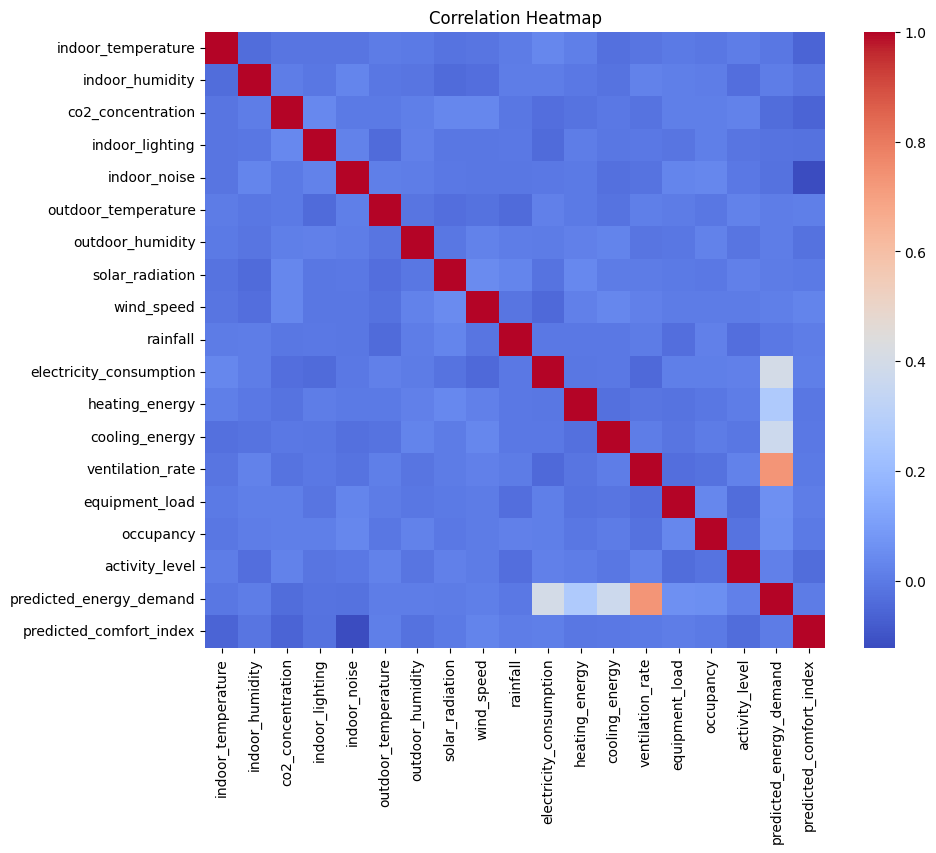

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [31]:
corr_target = corr["predicted_energy_demand"].sort_values(ascending=False)
print(corr_target)

predicted_energy_demand    1.000000
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
activity_level             0.018522
wind_speed                 0.011333
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
predicted_comfort_index    0.003568
rainfall                  -0.004161
indoor_temperature        -0.008106
indoor_lighting           -0.020631
indoor_noise              -0.024454
co2_concentration         -0.036466
Name: predicted_energy_demand, dtype: float64


In [32]:
selected_features = corr_target.index[1:6]  # top 5 excluding target
print(selected_features)

X_selected = df[selected_features]

Index(['ventilation_rate', 'electricity_consumption', 'cooling_energy',
       'heating_energy', 'equipment_load'],
      dtype='object')


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² =", r2)
print("RMSE =", rmse)

R² = 0.9572846590532547
RMSE = 1.9969445555858067


In [38]:
coefficients = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": model.coef_
})

print(coefficients)
print("Intercept =", model.intercept_)

                   Feature  Coefficient
0         ventilation_rate     0.049987
1  electricity_consumption     0.292907
2           cooling_energy     0.250048
3           heating_energy     0.247727
4           equipment_load     0.096911
Intercept = 1.4429581650362309


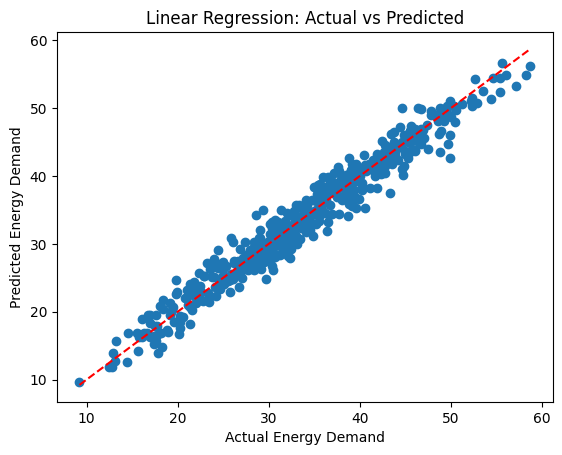

In [39]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy Demand")
plt.ylabel("Predicted Energy Demand")
plt.title("Linear Regression: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

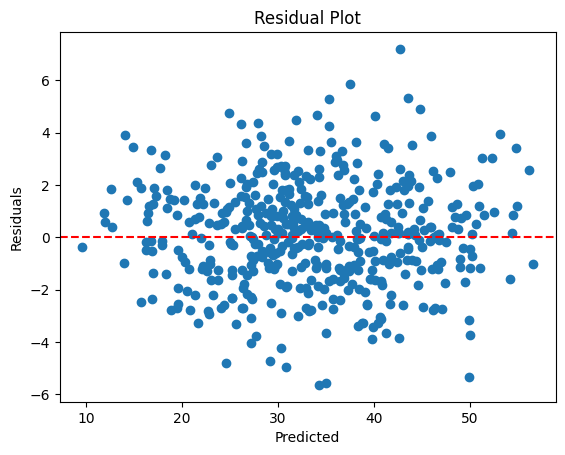

In [40]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()